In [1]:
%pip install -U duckduckgo-search langchain-community

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.7/4.7 MB 50.2 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2/2 [duckduckgo-search]
Note: you may need to restart the kernel to use updated packages.


In [2]:
from dotenv import load_dotenv

load_dotenv()

True

In [3]:
from langchain_google_genai import ChatGoogleGenerativeAI

llm = ChatGoogleGenerativeAI(model="gemini-2.5-flash")

/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [4]:
from langchain_core.tools import tool

@tool
def add(a: int, b: int) -> int:
    """숫자 a와 b를 더한 결과를 반환합니다."""
    return a + b

@tool
def multiply(a: int, b: int) -> int:
    """숫자 a와 b를 곱한 결과를 반환합니다."""
    return a * b

In [6]:
%pip install -U ddgs

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 863.1/863.1 kB 30.4 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7/7 [ddgs]
Note: you may need to restart the kernel to use updated packages.


In [8]:
from langchain_community.tools import DuckDuckGoSearchResults

search_tool = DuckDuckGoSearchResults()

In [9]:
from langgraph.prebuilt import ToolNode

tool_list = [add, multiply, search_tool]
llm_with_tools = llm.bind_tools(tool_list)
tool_node = ToolNode(tool_list)

In [10]:
from langgraph.graph import MessagesState, StateGraph

graph_builder = StateGraph(MessagesState)

In [11]:
def agent(state: MessagesState):
    messages = state['messages']
    response = llm_with_tools.invoke(messages)
    return {'messages': [response]}

In [12]:
from langgraph.graph import END

def should_continue(state: MessagesState):
    messages = state['messages']
    last_message = messages[-1]
    if last_message.tool_calls:
        return 'tools'
    return END

In [13]:
graph_builder.add_node('agent', agent)
graph_builder.add_node('tools', tool_node)

In [14]:
from langgraph.graph import START, END

graph_builder.add_edge(START, 'agent')
graph_builder.add_conditional_edges(
    'agent',
    should_continue,
    ['tools', END]
)
graph_builder.add_edge('tools', 'agent')

graph = graph_builder.compile()

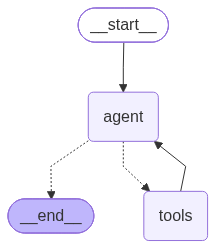

In [15]:
from IPython.display import Image, display

display(Image(graph.get_graph().draw_mermaid_png()))

In [17]:
from langchain_core.messages import HumanMessage

query = 'What currency is in Billy Giles\' birthplace?'
for chunk in graph.stream({'messages': [HumanMessage(query)]}, stream_mode='values'):
    chunk['messages'][-1].pretty_print()


================================ Human Message =================================

What currency is in Billy Giles' birthplace?
================================== Ai Message ==================================
Tool Calls:
  duckduckgo_results_json (8624bd30-6260-44ad-9673-f0e90704a05f)
 Call ID: 8624bd30-6260-44ad-9673-f0e90704a05f
  Args:
    query: Billy Giles birthplace
================================= Tool Message =================================
Name: duckduckgo_results_json

snippet: Billy Giles was born William Alexander Ellis Giles in Belfast, Northern Ireland on 3 September 1957, and grew up in Island Street, in loyalist east Belfast. His father Sam, worked as a plater in the nearby Harland & Wolff shipyard, and his mother, Lily was a housewife., title: Billy Giles - Wikipedia, link: https://en.wikipedia.org/wiki/Billy_Giles, snippet: Mar 26, 2024 · Billy Giles was born William Alexander Ellis Giles in Belfast, Northern Ireland on 3 September 1957, and grew up in Island Street